<a href="https://colab.research.google.com/github/erxuanqi/mental-health-app-ux-analysis/blob/main/notebooks/02_topic_modelling_level3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Level 3: Topic Modelling for Mental Health App Review Analysis

This notebook extends the previous Level 1 and Level 2 analysis of the MHARD mental health app review dataset.

The purpose of Level 3 is to use topic modelling to explore whether low-rating user reviews contain recurring experience-related themes, and whether these automatically discovered topics align with the pain point categories identified in Level 2.

This analysis is not intended to demonstrate complex machine learning performance. Instead, topic modelling is used as a supplementary validation method for UX-oriented interpretation.

## Research Aim

To identify recurring themes in low-rating mental health app reviews and compare them with the rule-based UX pain point categories from Level 2.

## Key Focus

- Low-rating user reviews
- Topic modelling as exploratory NLP
- Comparison with Level 2 pain point categories
- UX, digital health, and service design interpretation

In [22]:
# Level 3 Topic Modelling - Basic Setup

import pandas as pd
import numpy as np
import os

from pathlib import Path

# Show more columns and wider text in tables
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

print("Basic libraries imported successfully.")

Basic libraries imported successfully.


In [23]:
# Create project folders for Level 3 outputs

import os

folders = [
    "data",
    "data/raw",
    "data/processed",
    "outputs",
    "outputs/figures",
    "outputs/tables",
    "outputs/models"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created.")

Project folders created.


In [24]:
# Load MHARD dataset from the official GitHub repository

import pandas as pd
import numpy as np

full_url = "https://raw.githubusercontent.com/Sensify-Lab/MHARD/main/MHARD_dataset.csv"

df = pd.read_csv(full_url)

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded successfully.
Number of rows: 200972
Number of columns: 16


,UID,app_name,rating,date,review,review_cleaned,likes,response_date,response,pred_gpt3.5instruct,pred_gpt3.5turbo,pred_gpt4,pred_gemini1.5flash,pred_gemini1.5pro,pred_llama3.1_8b,pred_llama3.3_70b
0,1,chiku,5,"August 17, 2020","I'm digging it. journaling everything I do during the day. my only complaint is sometimes when editing, it's hard to scroll down to see the end of the text. the scroll bar is invisible on the far ...",im digging journaling everything day complaint sometimes editing hard scroll see end text scroll bar invisible far right side sometimes cant get work properly save scroll edit might getting used i...,30,"August 23, 2020","We have fixed the issue in our latest update (version 5.2) Thank you so much for your valuable feedback, it helped us improve the app. If there is anything else we can help you with, let us know a...",4.0,4.0,4.0,4.0,4.0,4.0,4.0
1,2,chiku,4,"December 22, 2020","I really like this app, however, the awesome smiley graphic is a bit unnerving. All of the other ones are cute, but the awesome guy really freaks me out and I think it should be redesigned. I've n...",really like app however awesome smiley graphic bit unnerving one cute awesome guy really freak think redesigned ive narrowed handful apps reflectly like setup chiku term layout journal ability fav...,18,"December 22, 2020","Thank you so much for taking out time to write a detailed review. We have forwarded it to our developers, and will definately fix the issues you are facing in our upcoming update. If there is anyt...",4.0,4.0,4.0,4.0,4.0,4.0,4.0
2,3,chiku,5,"March 02, 2022","I love this. It's so calming, and relaxing, and definitely one of my favorites. My only problem with it is that even with the unlimited subscription I bought, it only saves my first story. I try t...",love calming relaxing definitely one favorite problem even unlimited subscription bought save first story try journal wont save anyone know way fix really love app edit anyone else problem try uni...,62,NaN,NaN,4.0,4.0,4.0,4.0,4.0,4.0,4.0
3,4,chiku,4,"April 27, 2023","This app is really great! Its has many features and things you can do, while on other apps you have to pay to have them. But it has some problems. So, the first problem is that when you make a cha...",app really great many feature thing apps pay problem first problem make change refresh page doesnt really refresh close app open refresh also add photo select one one instead select fix problem wo...,56,NaN,NaN,4.0,4.0,4.0,4.0,4.0,4.0,4.0
4,5,chiku,4,"April 10, 2023","This app used to be amazing but now whenever I try to make a story it starts glitching and I have to refresh many times to upload on story. Even after trying to unistall and reinstall, the problem...",app used amazing whenever try make story start glitching refresh many time upload story even trying unistall reinstall problem didnt get fixed could please check problem would really appreciated l...,59,"April 13, 2023","We are really sorry for the inconvenience. We have forwarded your review to our team, and they are looking into the issue immediately.",2.0,2.0,2.0,2.0,3.0,3.0,2.0


In [25]:
# Basic cleaning for Level 3 topic modelling

df_clean = df.copy()

main_columns = [
    "UID",
    "app_name",
    "rating",
    "date",
    "review",
    "review_cleaned",
    "likes",
    "response_date",
    "response"
]

# Keep only the main columns needed for this project
df_clean = df_clean[main_columns]

# Remove rows without review text or rating
df_clean = df_clean.dropna(subset=["review", "rating"])

# Convert rating to numeric
df_clean["rating"] = pd.to_numeric(df_clean["rating"], errors="coerce")
df_clean = df_clean.dropna(subset=["rating"])
df_clean["rating"] = df_clean["rating"].astype(int)

# Remove duplicated original reviews from the same app
df_clean = df_clean.drop_duplicates(subset=["app_name", "review"])

# Ensure text columns are strings
df_clean["review"] = df_clean["review"].astype(str)
df_clean["review_cleaned"] = df_clean["review_cleaned"].astype(str)

# Remove rows where cleaned review text is empty
df_clean = df_clean[df_clean["review_cleaned"].str.strip() != ""]

print("Basic cleaning completed.")
print("Cleaned dataset shape:", df_clean.shape)

df_clean.head()

Basic cleaning completed.
Cleaned dataset shape: (194774, 9)


,UID,app_name,rating,date,review,review_cleaned,likes,response_date,response
0,1,chiku,5,"August 17, 2020","I'm digging it. journaling everything I do during the day. my only complaint is sometimes when editing, it's hard to scroll down to see the end of the text. the scroll bar is invisible on the far ...",im digging journaling everything day complaint sometimes editing hard scroll see end text scroll bar invisible far right side sometimes cant get work properly save scroll edit might getting used i...,30,"August 23, 2020","We have fixed the issue in our latest update (version 5.2) Thank you so much for your valuable feedback, it helped us improve the app. If there is anything else we can help you with, let us know a..."
1,2,chiku,4,"December 22, 2020","I really like this app, however, the awesome smiley graphic is a bit unnerving. All of the other ones are cute, but the awesome guy really freaks me out and I think it should be redesigned. I've n...",really like app however awesome smiley graphic bit unnerving one cute awesome guy really freak think redesigned ive narrowed handful apps reflectly like setup chiku term layout journal ability fav...,18,"December 22, 2020","Thank you so much for taking out time to write a detailed review. We have forwarded it to our developers, and will definately fix the issues you are facing in our upcoming update. If there is anyt..."
2,3,chiku,5,"March 02, 2022","I love this. It's so calming, and relaxing, and definitely one of my favorites. My only problem with it is that even with the unlimited subscription I bought, it only saves my first story. I try t...",love calming relaxing definitely one favorite problem even unlimited subscription bought save first story try journal wont save anyone know way fix really love app edit anyone else problem try uni...,62,NaN,NaN
3,4,chiku,4,"April 27, 2023","This app is really great! Its has many features and things you can do, while on other apps you have to pay to have them. But it has some problems. So, the first problem is that when you make a cha...",app really great many feature thing apps pay problem first problem make change refresh page doesnt really refresh close app open refresh also add photo select one one instead select fix problem wo...,56,NaN,NaN
4,5,chiku,4,"April 10, 2023","This app used to be amazing but now whenever I try to make a story it starts glitching and I have to refresh many times to upload on story. Even after trying to unistall and reinstall, the problem...",app used amazing whenever try make story start glitching refresh many time upload story even trying unistall reinstall problem didnt get fixed could please check problem would really appreciated l...,59,"April 13, 2023","We are really sorry for the inconvenience. We have forwarded your review to our team, and they are looking into the issue immediately."


In [26]:
# Create rating groups and extract low-rating reviews

def create_rating_group(rating):
    if rating <= 2:
        return "Low rating"
    elif rating == 3:
        return "Neutral rating"
    else:
        return "High rating"

df_clean["rating_group"] = df_clean["rating"].apply(create_rating_group)

# Use cleaned review text for topic modelling
df_clean["clean_text"] = df_clean["review_cleaned"]

# Remove empty cleaned text again as a safety check
df_clean = df_clean[df_clean["clean_text"].str.strip() != ""]

# Extract low-rating reviews
low_reviews = df_clean[df_clean["rating_group"] == "Low rating"].copy()

print("Rating group counts:")
print(df_clean["rating_group"].value_counts())

print("\nLow-rating reviews shape:", low_reviews.shape)

low_reviews[["app_name", "rating", "review", "clean_text"]].head()

Rating group counts:
rating_group
High rating       141642
Low rating         42322
Neutral rating     10810
Name: count, dtype: int64

Low-rating reviews shape: (42322, 11)


,app_name,rating,review,clean_text
5,chiku,1,"Right after i updated, the next time i opened the app all my previous stories had disappeared. Even when i tried to make a story it said no network and wouldn't upload. This app is broken. Used to...",right updated next time opened app previous story disappeared even tried make story said network wouldnt upload app broken used easy make entry doesnt even work lost everything youve done
9,chiku,1,I updated the app and It deleted all of my journal entries. Years of memories. Gone. I'm crying and dont know what to do. Was great before but this is awful,updated app deleted journal entry year memory gone im cry dont know great awful
15,chiku,1,"Even after the update, this app is still crashing when I write a journal for like more than 30 seconds. It's so frustrating 😪",even update app still crashing write journal like second frustrating
22,chiku,1,"This has left me with a bad experience as I found I couldn't find a way to delete an entry once added, which was frustrating. When I went to delete the account in the settings, it kept stating tha...",left bad experience found couldnt find way delete entry added frustrating went delete account setting kept stating password incorrect make sense considering used google account use app never promp...
32,chiku,1,"Yearly fee to add images to entries (every other diary app I've tried does this free), cannot skip moods or icons for entries and just write, like 10 tedious steps just to get to writing anything....",yearly fee add image entry every diary app ive tried free cannot skip mood icon entry write like tedious step get writing anything ugh tedious also make account login xp


In [27]:
# Prepare text data for topic modelling

# Calculate text length by number of words
low_reviews["word_count"] = low_reviews["clean_text"].apply(lambda x: len(str(x).split()))

print("Low-rating review length summary:")
print(low_reviews["word_count"].describe())

# Check very short reviews
print("\nNumber of reviews with fewer than 3 words:")
print((low_reviews["word_count"] < 3).sum())

print("\nNumber of reviews with fewer than 5 words:")
print((low_reviews["word_count"] < 5).sum())

# Preview short reviews
low_reviews[low_reviews["word_count"] < 5][["app_name", "rating", "review", "clean_text", "word_count"]].head(10)

Low-rating review length summary:
count    42322.000000
mean        18.768111
std         13.970443
min          1.000000
25%          8.000000
50%         15.000000
75%         27.000000
max        216.000000
Name: word_count, dtype: float64

Number of reviews with fewer than 3 words:
1870

Number of reviews with fewer than 5 words:
5561


,app_name,rating,review,clean_text,word_count
330,chiku,2,I dont open it now,dont open,2
485,chiku,1,Mandatory authentication with Google account,mandatory authentication google account,4
7402,intellect,1,It crashes as soon as I open it on Android 6.0,crash soon open android,4
7719,intellect,1,No way to turn off on obnoxious audio.,way turn obnoxious audio,4
7882,intellect,2,Very basic information and full of typos,basic information full typo,4
8535,intellect,1,"Very inaccurate results, not a successful one.",inaccurate result successful one,4
8593,intellect,1,A daily paper's horoscope is more accurate.,daily paper horoscope accurate,4
8683,intellect,1,Useless there isn't anyone to speak with,useless isnt anyone speak,4
8869,intellect,1,Very pricey. Not sure it's worth that much moola.,sure worth much moola,4
9361,intellect,2,"The goal of this app is very nice, but its design is not.",goal app nice design,4


In [28]:
# Filter low-rating reviews for topic modelling

topic_reviews = low_reviews[low_reviews["word_count"] >= 5].copy()

print("Original low-rating reviews:", low_reviews.shape[0])
print("Reviews kept for topic modelling:", topic_reviews.shape[0])
print("Reviews removed because they are too short:", low_reviews.shape[0] - topic_reviews.shape[0])

topic_reviews[["app_name", "rating", "clean_text", "word_count"]].head()

Original low-rating reviews: 42322
Reviews kept for topic modelling: 36761
Reviews removed because they are too short: 5561


,app_name,rating,clean_text,word_count
5,chiku,1,right updated next time opened app previous story disappeared even tried make story said network wouldnt upload app broken used easy make entry doesnt even work lost everything youve done,30
9,chiku,1,updated app deleted journal entry year memory gone im cry dont know great awful,14
15,chiku,1,even update app still crashing write journal like second frustrating,10
22,chiku,1,left bad experience found couldnt find way delete entry added frustrating went delete account setting kept stating password incorrect make sense considering used google account use app never promp...,41
32,chiku,1,yearly fee add image entry every diary app ive tried free cannot skip mood icon entry write like tedious step get writing anything ugh tedious also make account login xp,30


In [29]:
# Prepare document list for topic modelling

docs = topic_reviews["clean_text"].astype(str).tolist()

print("Number of documents for topic modelling:", len(docs))
print("\nExample document:")
print(docs[0])

Number of documents for topic modelling: 36761

Example document:
right updated next time opened app previous story disappeared even tried make story said network wouldnt upload app broken used easy make entry doesnt even work lost everything youve done


In [30]:
# TF-IDF vectorization for topic modelling

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.85,          # ignore very common words
    min_df=20,            # ignore very rare words
    max_features=5000,    # keep top 5000 terms
    stop_words="english",
    ngram_range=(1, 2)    # use single words and two-word phrases
)

tfidf_matrix = tfidf_vectorizer.fit_transform(docs)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (36761, 5000)


In [31]:
# Run NMF topic modelling

from sklearn.decomposition import NMF

n_topics = 10

nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    init="nndsvda",
    max_iter=500
)

nmf_topics = nmf_model.fit_transform(tfidf_matrix)

print("NMF topic modelling completed.")
print("Document-topic matrix shape:", nmf_topics.shape)

NMF topic modelling completed.
Document-topic matrix shape: (36761, 10)


In [32]:
# Extract top keywords for each NMF topic

feature_names = tfidf_vectorizer.get_feature_names_out()

def get_top_topic_keywords(model, feature_names, n_top_words=15):
    topic_keywords = []

    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]

        topic_keywords.append({
            "topic_id": topic_idx,
            "top_keywords": ", ".join(top_words)
        })

    return pd.DataFrame(topic_keywords)

topic_keywords_df = get_top_topic_keywords(
    nmf_model,
    feature_names,
    n_top_words=15
)

topic_keywords_df

,topic_id,top_keywords
0,0,"pay, app, like, good, really, thing, premium, free, im, meditation, sleep, used, great, locked, make"
1,1,"phone, app, uninstall, setting, update, installed, google, app phone, apps, stop, permission, remove, disable, useless, install"
2,2,"free, trial, free trial, day, day free, day trial, card, free app, app free, free day, try, payment, credit, credit card, charged"
3,3,"subscription, cancel, charged, refund, service, cancel subscription, year, cancelled, customer, month, charge, money, google, email, customer service"
4,4,"dont, want, dont want, need, dont need, know, want app, uninstall, dont know, app dont, dont like, delete, want phone, like, remove"
5,5,"account, let, wont, sign, wont let, try, wrong, email, log, tried, went, password, went wrong, say, create"
6,6,"use, use app, app, dont use, app use, pay use, able use, want use, able, use free, used use, dont, used, app dont, use phone"
7,7,"help, people, mental, health, mental health, money, need, therapist, listener, like, feel, issue, talk, really, make"
8,8,"time, waste, waste time, dont waste, day, money, therapist, tried, ive, dont, app, waste money, multiple, time money, screen"
9,9,"work, doesnt, doesnt work, app doesnt, app, open, app work, screen, notification, properly, update, mode, button, work properly, block"


In [33]:
# Assign dominant topic to each review

topic_reviews = topic_reviews.copy()

topic_reviews["dominant_topic"] = nmf_topics.argmax(axis=1)
topic_reviews["topic_weight"] = nmf_topics.max(axis=1)

print("Dominant topic assigned.")
print(topic_reviews["dominant_topic"].value_counts().sort_index())

topic_reviews[["app_name", "rating", "clean_text", "dominant_topic", "topic_weight"]].head()

Dominant topic assigned.
dominant_topic
0    5652
1    4724
2    3192
3    3960
4    2892
5    3144
6    3153
7    4306
8    3170
9    2568
Name: count, dtype: int64


,app_name,rating,clean_text,dominant_topic,topic_weight
5,chiku,1,right updated next time opened app previous story disappeared even tried make story said network wouldnt upload app broken used easy make entry doesnt even work lost everything youve done,9,0.064561
9,chiku,1,updated app deleted journal entry year memory gone im cry dont know great awful,4,0.030148
15,chiku,1,even update app still crashing write journal like second frustrating,1,0.020456
22,chiku,1,left bad experience found couldnt find way delete entry added frustrating went delete account setting kept stating password incorrect make sense considering used google account use app never promp...,5,0.059069
32,chiku,1,yearly fee add image entry every diary app ive tried free cannot skip mood icon entry write like tedious step get writing anything ugh tedious also make account login xp,5,0.031713


In [34]:
# Create topic summary table

topic_counts = topic_reviews["dominant_topic"].value_counts().sort_index()

topic_summary_df = pd.DataFrame({
    "topic_id": topic_counts.index,
    "review_count": topic_counts.values
})

topic_summary_df["percentage"] = (
    topic_summary_df["review_count"] / topic_summary_df["review_count"].sum() * 100
).round(2)

# Add topic keywords
topic_summary_df = topic_summary_df.merge(topic_keywords_df, on="topic_id", how="left")

# Add average rating by topic
avg_rating_by_topic = topic_reviews.groupby("dominant_topic")["rating"].mean().round(2)

topic_summary_df["average_rating"] = topic_summary_df["topic_id"].map(avg_rating_by_topic)

topic_summary_df = topic_summary_df.sort_values("review_count", ascending=False)

topic_summary_df

,topic_id,review_count,percentage,top_keywords,average_rating
0,0,5652,15.37,"pay, app, like, good, really, thing, premium, free, im, meditation, sleep, used, great, locked, make",1.35
1,1,4724,12.85,"phone, app, uninstall, setting, update, installed, google, app phone, apps, stop, permission, remove, disable, useless, install",1.11
7,7,4306,11.71,"help, people, mental, health, mental health, money, need, therapist, listener, like, feel, issue, talk, really, make",1.23
3,3,3960,10.77,"subscription, cancel, charged, refund, service, cancel subscription, year, cancelled, customer, month, charge, money, google, email, customer service",1.12
2,2,3192,8.68,"free, trial, free trial, day, day free, day trial, card, free app, app free, free day, try, payment, credit, credit card, charged",1.18
8,8,3170,8.62,"time, waste, waste time, dont waste, day, money, therapist, tried, ive, dont, app, waste money, multiple, time money, screen",1.25
6,6,3153,8.58,"use, use app, app, dont use, app use, pay use, able use, want use, able, use free, used use, dont, used, app dont, use phone",1.25
5,5,3144,8.55,"account, let, wont, sign, wont let, try, wrong, email, log, tried, went, password, went wrong, say, create",1.19
4,4,2892,7.87,"dont, want, dont want, need, dont need, know, want app, uninstall, dont know, app dont, dont like, delete, want phone, like, remove",1.18
9,9,2568,6.99,"work, doesnt, doesnt work, app doesnt, app, open, app work, screen, notification, properly, update, mode, button, work properly, block",1.30


In [35]:
# View representative reviews for each topic

def show_representative_reviews(topic_id, n=5):
    sample = (
        topic_reviews[topic_reviews["dominant_topic"] == topic_id]
        .sort_values("topic_weight", ascending=False)
        [["app_name", "rating", "clean_text", "topic_weight"]]
        .head(n)
    )
    return sample

# Show representative reviews for all topics
for topic_id in sorted(topic_reviews["dominant_topic"].unique()):
    print("=" * 80)
    print(f"Topic {topic_id}")
    print("Keywords:")
    print(topic_keywords_df.loc[topic_keywords_df["topic_id"] == topic_id, "top_keywords"].values[0])
    print("\nRepresentative reviews:")

    display(show_representative_reviews(topic_id, n=5))

Topic 0
Keywords:
pay, app, like, good, really, thing, premium, free, im, meditation, sleep, used, great, locked, make

Representative reviews:


,app_name,rating,clean_text,topic_weight
43951,headspace,1,giving onestar review pay get every feature know stuff like voice mod youtube apps download headspace meditation sleep sound there reason pay app like youtube premium discord nitro still typically...,0.075984
48992,headspace,2,great app used didnt tp pay everything great needed pay understandable need pay everything basically cant use app unless pay understand everyone involved headspace need pay check madness,0.064894
72658,calm,2,app could literally good really really ruin amount thing pay know there option pay im completely honest awful im position cant pay cant get peace mind pay honestly could good app limited amount th...,0.064548
113695,youper,1,im devastated used last year really great success fact ive recommending others thinking free pandemic made need apparently everything locked wanting pay premium feature id pay app cant pay subscri...,0.059485
70331,calm,2,pay everything half thing listened locked isnt free ive always like never like app never thing pay soundscapes used listen rain locked want free trial pay full price app,0.057488


Topic 1
Keywords:
phone, app, uninstall, setting, update, installed, google, app phone, apps, stop, permission, remove, disable, useless, install

Representative reviews:


,app_name,rating,clean_text,topic_weight
139274,digitalwellbeing,1,cant take phone nothing nothing,0.167303
143749,digitalwellbeing,1,odea cant even find phone,0.167303
140883,digitalwellbeing,1,app randomlly show phone would install phone,0.152546
139229,digitalwellbeing,1,useless cant uninstall unrooted phone,0.128173
140186,digitalwellbeing,1,uninstalled still phone get garbage phone,0.124022


Topic 2
Keywords:
free, trial, free trial, day, day free, day trial, card, free app, app free, free day, try, payment, credit, credit card, charged

Representative reviews:


...

,app_name,rating,clean_text,topic_weight
17469,talklife,1,outdated really doe soothing help user feel actuvly attracts people mental health issue anything actualy provide real help people mental health issue try help people app teenager,0.135949
23893,happify,1,im convinced seems overly simplified doesnt seem mental health condition friendly people without would nice acknowledged mental health condition app clarified app made people mental health issue i...,0.127609
132250,breeze,1,love find something might help mental health end pay like part mental health issue money money help mental health yall suck,0.126298
132221,breeze,1,app must think people bit wealth need mental health help way people like afford many u struggling inflation,0.120536
118061,reflectly,2,really good set etc cute logo good app however really dont agree mental health apps making pay good many people need help need way vent mental health increasing people desperate help people see ap...,0.118989


Topic 8
Keywords:
time, waste, waste time, dont waste, day, money, therapist, tried, ive, dont, app, waste money, multiple, time money, screen

Representative reviews:


,app_name,rating,clean_text,topic_weight
133189,breeze,1,cant anything without money waste time,0.211742
132911,breeze,1,find helpful anyway waste time,0.188918
36205,dailybean,1,app limited day waste time,0.175540
192932,woebot,1,tried mere curiosity real waste time,0.174417
100991,welltory,1,dont even waste time installing ask account necessary totally waste time,0.170674


Topic 9
Keywords:
work, doesnt, doesnt work, app doesnt, app, open, app work, screen, notification, properly, update, mode, button, work properly, block

Representative reviews:


,app_name,rating,clean_text,topic_weight
170569,sharecare,1,app doesnt work already someone account,0.212422
33501,cerebral,1,doesnt work well many bug,0.207389
124331,stoppanic,1,app doesnt work help say would,0.203240
24544,happify,1,first website doesnt work downloaded app app doesnt work either make happy way,0.197886
143751,digitalwellbeing,1,doesnt work cant even set nothing phone,0.193030


In [36]:
# Manually interpret NMF topics based on keywords and representative reviews

topic_labels = {
    0: "Pricing, premium access, and locked features",
    1: "Phone settings, installation, and app removal issues",
    2: "Free trial, payment card, and trial conversion",
    3: "Subscription cancellation, refunds, and unexpected charges",
    4: "General rejection, unwanted app experience, and deletion intent",
    5: "Account, login, email, and password problems",
    6: "Basic usability and inability to use the app",
    7: "Mental health support needs and perceived service value",
    8: "Wasted time, wasted money, and failed therapy experience",
    9: "Technical malfunction, app not working, and update problems"
}

topic_summary_df["interpreted_topic"] = topic_summary_df["topic_id"].map(topic_labels)

topic_summary_df[
    ["topic_id", "interpreted_topic", "review_count", "percentage", "average_rating", "top_keywords"]
]

,topic_id,interpreted_topic,review_count,percentage,average_rating,top_keywords
0,0,"Pricing, premium access, and locked features",5652,15.37,1.35,"pay, app, like, good, really, thing, premium, free, im, meditation, sleep, used, great, locked, make"
1,1,"Phone settings, installation, and app removal issues",4724,12.85,1.11,"phone, app, uninstall, setting, update, installed, google, app phone, apps, stop, permission, remove, disable, useless, install"
7,7,Mental health support needs and perceived service value,4306,11.71,1.23,"help, people, mental, health, mental health, money, need, therapist, listener, like, feel, issue, talk, really, make"
3,3,"Subscription cancellation, refunds, and unexpected charges",3960,10.77,1.12,"subscription, cancel, charged, refund, service, cancel subscription, year, cancelled, customer, month, charge, money, google, email, customer service"
2,2,"Free trial, payment card, and trial conversion",3192,8.68,1.18,"free, trial, free trial, day, day free, day trial, card, free app, app free, free day, try, payment, credit, credit card, charged"
8,8,"Wasted time, wasted money, and failed therapy experience",3170,8.62,1.25,"time, waste, waste time, dont waste, day, money, therapist, tried, ive, dont, app, waste money, multiple, time money, screen"
6,6,Basic usability and inability to use the app,3153,8.58,1.25,"use, use app, app, dont use, app use, pay use, able use, want use, able, use free, used use, dont, used, app dont, use phone"
5,5,"Account, login, email, and password problems",3144,8.55,1.19,"account, let, wont, sign, wont let, try, wrong, email, log, tried, went, password, went wrong, say, create"
4,4,"General rejection, unwanted app experience, and deletion intent",2892,7.87,1.18,"dont, want, dont want, need, dont need, know, want app, uninstall, dont know, app dont, dont like, delete, want phone, like, remove"
9,9,"Technical malfunction, app not working, and update problems",2568,6.99,1.30,"work, doesnt, doesnt work, app doesnt, app, open, app work, screen, notification, properly, update, mode, button, work properly, block"


In [37]:
# Map topic model results to Level 2 pain point categories

level2_mapping = {
    0: "Pricing / Subscription",
    1: "Technical Issues / Usability",
    2: "Pricing / Subscription",
    3: "Pricing / Subscription",
    4: "Other / Unclassified",
    5: "Account / Login Issues",
    6: "Usability / Interface",
    7: "Content Quality / Effectiveness",
    8: "Content Quality / Effectiveness + Pricing / Subscription",
    9: "Technical Issues"
}

topic_summary_df["related_level2_pain_point"] = topic_summary_df["topic_id"].map(level2_mapping)

topic_summary_df[
    [
        "topic_id",
        "interpreted_topic",
        "related_level2_pain_point",
        "review_count",
        "percentage",
        "average_rating",
        "top_keywords"
    ]
]

,topic_id,interpreted_topic,related_level2_pain_point,review_count,percentage,average_rating,top_keywords
0,0,"Pricing, premium access, and locked features",Pricing / Subscription,5652,15.37,1.35,"pay, app, like, good, really, thing, premium, free, im, meditation, sleep, used, great, locked, make"
1,1,"Phone settings, installation, and app removal issues",Technical Issues / Usability,4724,12.85,1.11,"phone, app, uninstall, setting, update, installed, google, app phone, apps, stop, permission, remove, disable, useless, install"
7,7,Mental health support needs and perceived service value,Content Quality / Effectiveness,4306,11.71,1.23,"help, people, mental, health, mental health, money, need, therapist, listener, like, feel, issue, talk, really, make"
3,3,"Subscription cancellation, refunds, and unexpected charges",Pricing / Subscription,3960,10.77,1.12,"subscription, cancel, charged, refund, service, cancel subscription, year, cancelled, customer, month, charge, money, google, email, customer service"
2,2,"Free trial, payment card, and trial conversion",Pricing / Subscription,3192,8.68,1.18,"free, trial, free trial, day, day free, day trial, card, free app, app free, free day, try, payment, credit, credit card, charged"
8,8,"Wasted time, wasted money, and failed therapy experience",Content Quality / Effectiveness + Pricing / Subscription,3170,8.62,1.25,"time, waste, waste time, dont waste, day, money, therapist, tried, ive, dont, app, waste money, multiple, time money, screen"
6,6,Basic usability and inability to use the app,Usability / Interface,3153,8.58,1.25,"use, use app, app, dont use, app use, pay use, able use, want use, able, use free, used use, dont, used, app dont, use phone"
5,5,"Account, login, email, and password problems",Account / Login Issues,3144,8.55,1.19,"account, let, wont, sign, wont let, try, wrong, email, log, tried, went, password, went wrong, say, create"
4,4,"General rejection, unwanted app experience, and deletion intent",Other / Unclassified,2892,7.87,1.18,"dont, want, dont want, need, dont need, know, want app, uninstall, dont know, app dont, dont like, delete, want phone, like, remove"
9,9,"Technical malfunction, app not working, and update problems",Technical Issues,2568,6.99,1.30,"work, doesnt, doesnt work, app doesnt, app, open, app work, screen, notification, properly, update, mode, button, work properly, block"


In [38]:
# Save topic modelling tables

topic_summary_output_path = "outputs/tables/level3_topic_summary_table.csv"
topic_keywords_output_path = "outputs/tables/level3_topic_keywords.csv"
topic_reviews_output_path = "outputs/tables/level3_topic_reviews_with_dominant_topic.csv"

# Save final topic summary table
topic_summary_df.to_csv(topic_summary_output_path, index=False)

# Save topic keywords
topic_keywords_df.to_csv(topic_keywords_output_path, index=False)

# Save review-level topic assignments
topic_reviews.to_csv(topic_reviews_output_path, index=False)

print("Topic summary table saved to:", topic_summary_output_path)
print("Topic keywords saved to:", topic_keywords_output_path)
print("Review-level topic assignments saved to:", topic_reviews_output_path)

Topic summary table saved to: outputs/tables/level3_topic_summary_table.csv
Topic keywords saved to: outputs/tables/level3_topic_keywords.csv
Review-level topic assignments saved to: outputs/tables/level3_topic_reviews_with_dominant_topic.csv


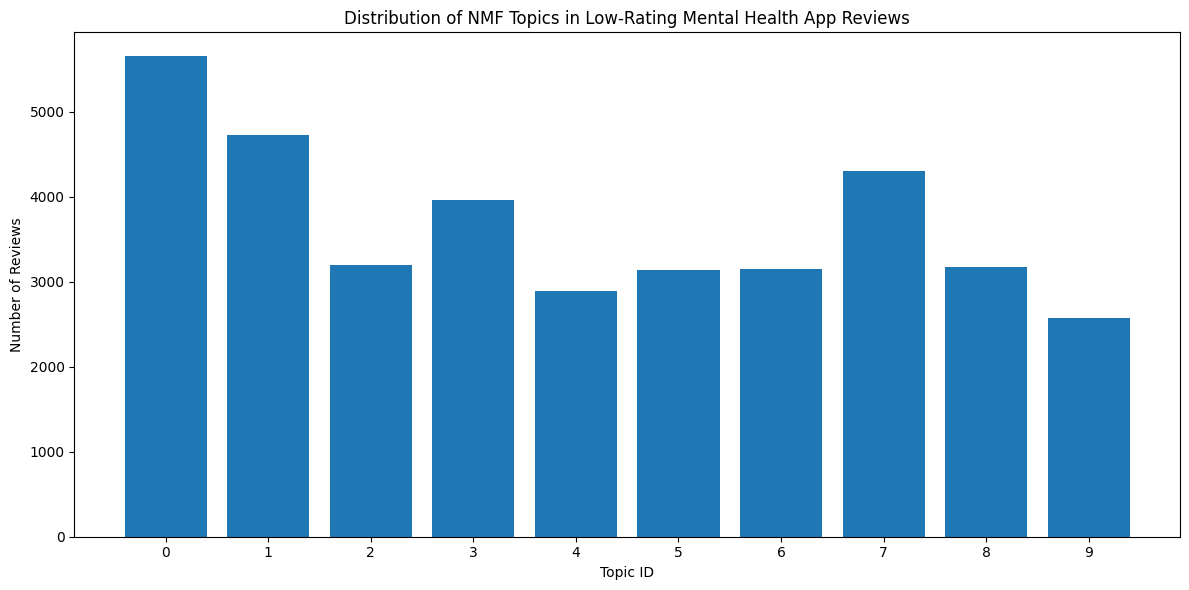

In [39]:
# Plot topic distribution

import matplotlib.pyplot as plt

plot_df = topic_summary_df.sort_values("topic_id")

plt.figure(figsize=(12, 6))
plt.bar(
    plot_df["topic_id"].astype(str),
    plot_df["review_count"]
)

plt.xlabel("Topic ID")
plt.ylabel("Number of Reviews")
plt.title("Distribution of NMF Topics in Low-Rating Mental Health App Reviews")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

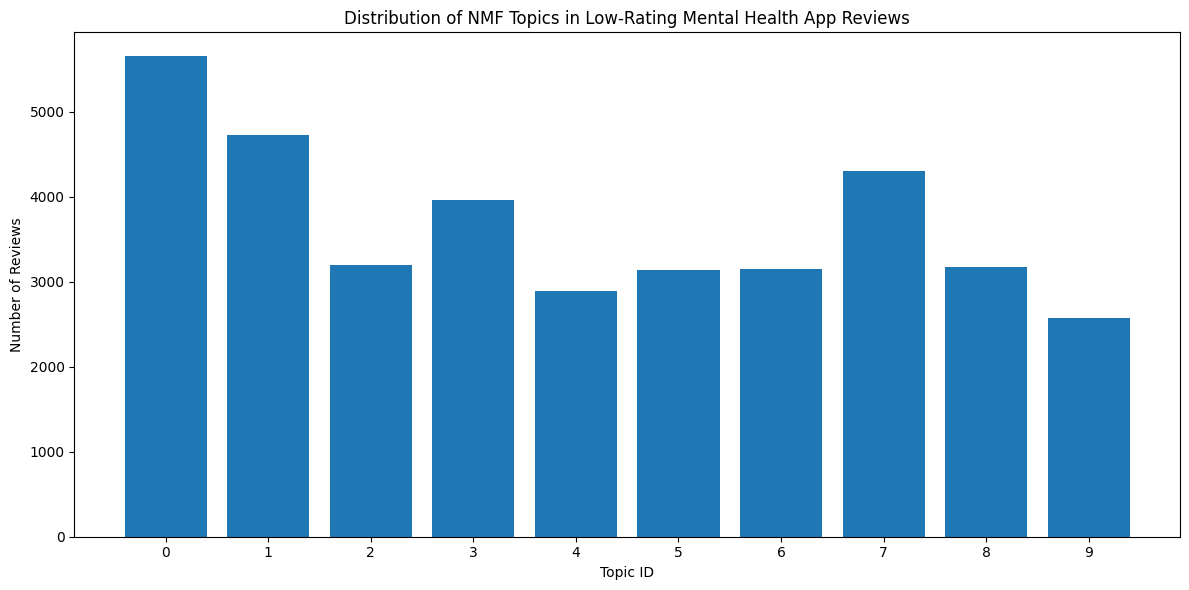

Figure saved to: outputs/figures/level3_topic_distribution.png


In [40]:
# Save topic distribution figure

figure_output_path = "outputs/figures/level3_topic_distribution.png"

plt.figure(figsize=(12, 6))
plt.bar(
    plot_df["topic_id"].astype(str),
    plot_df["review_count"]
)

plt.xlabel("Topic ID")
plt.ylabel("Number of Reviews")
plt.title("Distribution of NMF Topics in Low-Rating Mental Health App Reviews")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(figure_output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", figure_output_path)

## Level 3 Topic Modelling Results

This section applies NMF topic modelling to low-rating mental health app reviews.

A total of 36,761 low-rating reviews were used for topic modelling after filtering out very short reviews with fewer than 5 words. The model identified 10 topics from the review text.

The purpose of this analysis is not to build a predictive machine learning model, but to use topic modelling as an exploratory NLP method. The topics are interpreted as recurring user experience problems and compared with the pain point categories developed in Level 2.

Overall, the topic model identified several themes that align with the Level 2 pain point classification, including:

- Pricing and subscription problems
- Free trial and payment card issues
- Subscription cancellation, refund, and unexpected charge problems
- Account, login, and password problems
- Technical malfunction and app update problems
- Usability and inability to use the app
- Content quality, perceived support value, and failed therapy experiences

This suggests that the rule-based Level 2 pain point categories are partly supported by an unsupervised topic modelling approach.

## Interpretation of Topic Modelling Results

The NMF model produced 10 topics. Each topic was interpreted manually by examining both the top keywords and representative reviews.

Several topics were strongly aligned with the Level 2 pain point categories:

**Pricing / Subscription**

Topic 0, Topic 2, and Topic 3 all relate to payment, premium access, free trials, subscription cancellation, refunds, and unexpected charges. This confirms that pricing and subscription issues are a major source of dissatisfaction in low-rating mental health app reviews.

**Technical Issues**

Topic 1 and Topic 9 relate to installation problems, app updates, app removal, notifications, screens, buttons, and cases where the app does not work properly. These topics support the Level 2 technical issue category.

**Account / Login Issues**

Topic 5 captures account, sign-in, email, password, and account creation problems. This closely matches the Level 2 account/login category.

**Usability / Interface**

Topic 6 captures reviews where users describe being unable to use the app or finding the app difficult to use. This supports the Level 2 usability/interface category.

**Content Quality / Effectiveness**

Topic 7 and Topic 8 relate to mental health support needs, perceived lack of value, ineffective therapy experience, wasted time, and wasted money. These topics connect to content quality, perceived effectiveness, and service value.

**Other / Unclassified**

Topic 4 is more general and includes broad rejection, deletion intent, and unwanted app experience. This topic is less specific and overlaps with the Level 2 Other/Unclassified category.

Taken together, the topic modelling results provide an additional layer of validation for the Level 2 analysis. The model does not perfectly reproduce the rule-based categories, but it independently surfaces similar UX problems from the low-rating review text.

In [41]:
# Create a written Level 3 summary for README / project documentation

level3_summary = """
## Level 3: Topic Modelling

In Level 3, topic modelling was applied to low-rating mental health app reviews to explore whether recurring user experience problems could be identified automatically from review text.

After basic cleaning, 42,322 low-rating reviews were identified. Reviews with fewer than 5 words were removed to improve topic modelling quality, leaving 36,761 reviews for analysis.

A TF-IDF + NMF topic modelling approach was used. NMF was selected because it is stable, interpretable, and suitable for extracting keyword-based topics from short app review texts.

The model identified 10 topics. These topics were manually interpreted by examining the top keywords and representative reviews. Several automatically discovered topics aligned with the Level 2 rule-based pain point categories.

Key topic modelling findings:

- Pricing and subscription issues appeared across multiple topics, including premium access, free trials, cancellation, refunds, and unexpected charges.
- Technical problems appeared in topics related to installation, updates, notifications, screens, buttons, and cases where the app did not work properly.
- Account and login problems appeared as a distinct topic involving sign-in, email, password, and account creation issues.
- Usability problems appeared in topics where users described being unable to use the app or not wanting to continue using it.
- Content quality and perceived effectiveness appeared in topics related to mental health support needs, therapy experience, wasted time, and perceived lack of value.

Overall, the topic modelling results provide additional support for the Level 2 pain point classification. While the model does not perfectly reproduce the rule-based categories, it independently surfaces similar user experience problems from low-rating review text.

This strengthens the project’s main argument: low-rating mental health app reviews contain recurring UX pain points that can be translated into digital health and service design insights.
"""

print(level3_summary)


## Level 3: Topic Modelling

In Level 3, topic modelling was applied to low-rating mental health app reviews to explore whether recurring user experience problems could be identified automatically from review text.

After basic cleaning, 42,322 low-rating reviews were identified. Reviews with fewer than 5 words were removed to improve topic modelling quality, leaving 36,761 reviews for analysis.

A TF-IDF + NMF topic modelling approach was used. NMF was selected because it is stable, interpretable, and suitable for extracting keyword-based topics from short app review texts.

The model identified 10 topics. These topics were manually interpreted by examining the top keywords and representative reviews. Several automatically discovered topics aligned with the Level 2 rule-based pain point categories.

Key topic modelling findings:

- Pricing and subscription issues appeared across multiple topics, including premium access, free trials, cancellation, refunds, and unexpected charges.
- T

In [42]:
# Save Level 3 written summary

summary_output_path = "outputs/tables/level3_topic_modelling_summary.txt"

with open(summary_output_path, "w", encoding="utf-8") as f:
    f.write(level3_summary)

print("Level 3 summary saved to:", summary_output_path)

Level 3 summary saved to: outputs/tables/level3_topic_modelling_summary.txt


In [43]:
# Check all Level 3 output files

import os

level3_files = [
    "outputs/tables/level3_topic_summary_table.csv",
    "outputs/tables/level3_topic_keywords.csv",
    "outputs/tables/level3_topic_reviews_with_dominant_topic.csv",
    "outputs/tables/level3_topic_modelling_summary.txt",
    "outputs/figures/level3_topic_distribution.png"
]

for file_path in level3_files:
    if os.path.exists(file_path):
        print("Found:", file_path)
    else:
        print("Missing:", file_path)

Found: outputs/tables/level3_topic_summary_table.csv
Found: outputs/tables/level3_topic_keywords.csv
Found: outputs/tables/level3_topic_reviews_with_dominant_topic.csv
Found: outputs/tables/level3_topic_modelling_summary.txt
Found: outputs/figures/level3_topic_distribution.png
